In [16]:
# Set up sys.path so that 'src/spindle_dev' is importable as 'spindle_dev'
import sys
import importlib
from pathlib import Path

project_root = '..'
src_path = Path(project_root) / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import spindle_dev
# Reload to pick up code changes without restarting the kernel
importlib.reload(spindle_dev)

<module 'spindle_dev' from 'd:\\SPINDLE\\spindle_dev\\Split_test\\..\\src\\spindle_dev\\__init__.py'>

C:\Users\Admin\AppData\Local\Temp\ipykernel_18196\1149110262.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["Cluster"], spot_size=13)


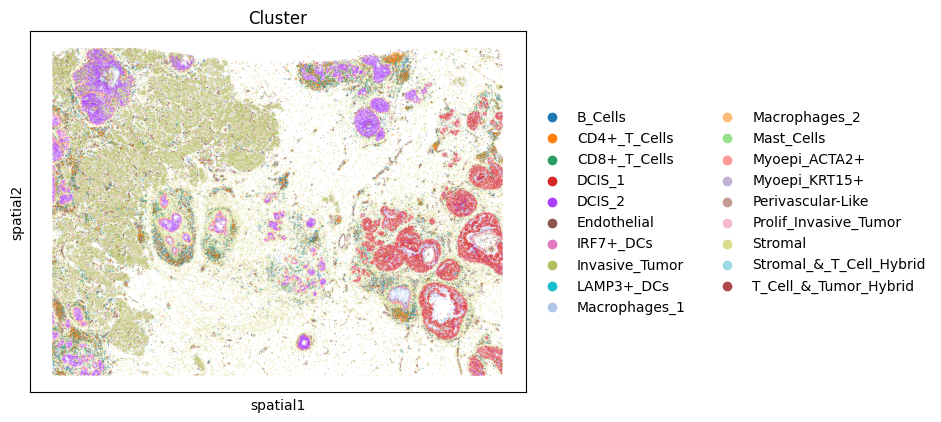

In [17]:
import scanpy as sc
adata = sc.read_h5ad("../dataset/adata.h5ad")
adata = adata[adata.obs.loc[adata.obs.Cluster != "Unlabeled"].index, :].copy()
sc.pl.spatial(adata, color=["Cluster"], spot_size=13)

In [18]:
# Reload spindle_dev metrics, index, and package after code changes
import importlib
import spindle_dev
import spindle_dev.metrics as metrics
import spindle_dev.index as index
import spindle_dev.preprocessing as preprocessing
import spindle_dev.plotting as plotting

# Reload in dependency order so new symbols are available
importlib.reload(metrics)
importlib.reload(index)
importlib.reload(preprocessing)
importlib.reload(plotting)
importlib.reload(spindle_dev)
import spindle_dev.typing as typing
importlib.reload(typing)
import spindle_dev.test as test
import spindle_dev.search as search
importlib.reload(test)
importlib.reload(search)

<module 'spindle_dev.search' from 'd:\\SPINDLE\\spindle_dev\\Split_test\\..\\src\\spindle_dev\\search.py'>

In [19]:
def prepare_to_index(adata):
    coords = adata.obsm["spatial"]
    tiles = preprocessing.build_quadtree_tiles(coords, max_pts=200, min_side=0.0, max_depth=40)
    num_genes = adata.n_vars
    genes_work, gene_idx = spindle_dev.preprocessing.topvar_genes(adata, G=num_genes)  
    tile_covs = spindle_dev.preprocessing.build_tile_covs_full(adata, tiles, gene_idx, n_jobs=8, eps=1e-6)

    return tiles, tile_covs, genes_work


def run_index(tiles, tile_covs, genes_work, adata, resolution=0.2, min_final_size=20):
    data = index.ProcessedData(tiles, tile_covs, genes_work, adata.n_obs)
    data.reduce_dim(num_pca_components=30, n_components=2, do_umap=True)
    data.cluster_spds(cluster_distance="tree", cluster_method="leiden", resolution=resolution)
    data.assign_label_to_spots()
    data.get_corr_mean_by_cluster()
    out_dict = data.get_adaptive_runs(find_blocks=True, with_size_guard=True,min_final_size=min_final_size,max_final_size=100)
    return data, out_dict

In [20]:
tiles, tile_covs, genes_work = prepare_to_index(adata)

In [21]:
import numpy as np

np.random.seed(4) 
num_total_tiles = len(tiles)
test_ratio = 0.05
num_test = int(num_total_tiles * test_ratio)

all_indices = np.arange(num_total_tiles)
test_idx = np.random.choice(all_indices, size=num_test, replace=False)
train_idx = np.setdiff1d(all_indices, test_idx)

train_tiles = [tiles[i] for i in train_idx]
train_tile_covs = [tile_covs[i] for i in train_idx]
test_tiles = [tiles[i] for i in test_idx]
test_tile_covs = [tile_covs[i] for i in test_idx]

print(f"Total tiles: {num_total_tiles} | Training/Indexed: {len(train_tiles)} | Held out/Testing: {len(test_tiles)}")

Total tiles: 2081 | Training/Indexed: 1977 | Held out/Testing: 104


In [22]:
data, out_dict = run_index(train_tiles, train_tile_covs, genes_work, adata, resolution=0.2, min_final_size=15)

[2026-03-25 13:15:49,484] INFO spindle_dev.index: Clustering SPD-s using 'tree' distance.
[2026-03-25 13:15:49,484] INFO spindle_dev.index: Building ultrametric features from SPD matrices.
[2026-03-25 13:15:55,409] INFO spindle_dev.index: Computing latent features from the tree representations.
[2026-03-25 13:15:56,109] INFO spindle_dev.index: Reducing latent features to 30 dimensions using PCA.
[2026-03-25 13:15:58,778] INFO spindle_dev.index: Explained variance ratios by PCA components: [0.06824755 0.05399017 0.02646343 0.01933549 0.01281479 0.01027342
 0.00785551 0.00739578 0.0067344  0.00647651 0.00502424 0.00467264
 0.00426736 0.00420122 0.00381818 0.00366991 0.00358403 0.00351903
 0.00337774 0.00319379 0.00310013 0.00308487 0.0030243  0.00301075
 0.00295645 0.00287865 0.00284431 0.00275261 0.00271681 0.00267981]
[2026-03-25 13:15:58,778] INFO spindle_dev.index: Reducing latent features to 2 dimensions using UMAP.
d:\SPINDLE\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

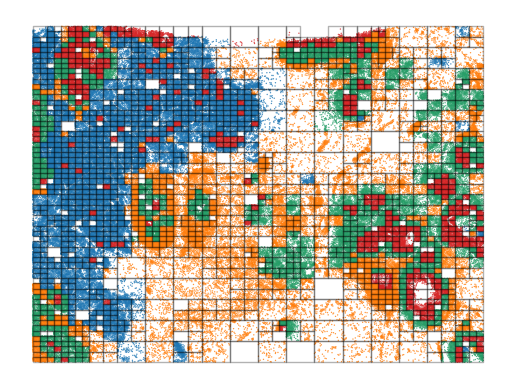

In [23]:
import matplotlib.pylab as plt
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
import numpy as np

palette = sc.pl.palettes.default_20
point_colors = [palette[lab] for lab in data.spot_label.values()]
labels = data.labels
indices = np.array([int(i) for i in data.spot_label.keys()])
coords = adata.obsm['spatial']
plt.scatter(coords[indices,0], coords[indices,1], s=1, c=point_colors, lw=0, alpha=0.8)
patches = []
for t in tiles:
    bbox = t.bbox if hasattr(t, "bbox") else t["bbox"]  # (xmin,ymin,xmax,ymax)
    x0, y0, x1, y1 = bbox
    patches.append(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False))
pc = PatchCollection(patches, match_original=True, linewidths=0.2, edgecolors='b', alpha=0.3)
# add collection
ax = plt.gca()
ax.add_collection(pc)
ax.invert_yaxis()
ax.axis('off')

plt.show()

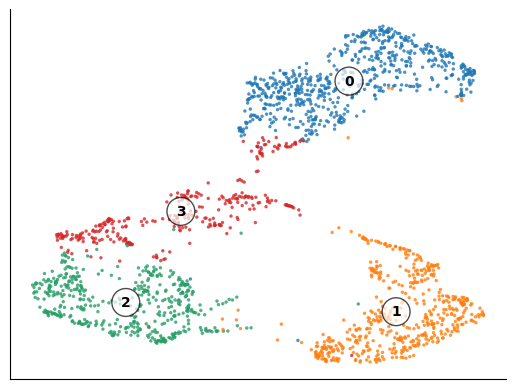

In [24]:
# Create colors for clusters
import numpy as np
import matplotlib.pyplot as plt
n_clusters = len(set(data.labels))
# Use Scanpy's default_20 palette for consistency
palette = sc.pl.palettes.default_20
cluster_colors = [palette[lab] for lab in data.labels]
plt.scatter(data.latent['umap'][:,0], data.latent['umap'][:,1], s=6, lw=0, alpha=0.8, c=cluster_colors)
# Write label on the plot
# with backgrond circle for better visibility
# and bold font
for i in range(n_clusters):
    cluster_points = data.latent['umap'][data.labels == i]
    if len(cluster_points) == 0:
        continue
    x_mean = np.mean(cluster_points[:,0])
    y_mean = np.mean(cluster_points[:,1])
    plt.text(x_mean, y_mean, str(i), color='black', fontsize=10, ha='center', va='center', fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='circle,pad=0.5', alpha=0.7))
# take away top and right border
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# remove axis ticks
ax.set_xticks([])
ax.set_yticks([])

plt.show()

In [25]:
epsilon_block_wise_dict = {}
epsilon_dict = {}
for cluster_id in set(data.labels):
    eps_per_block, eps_elbow_per_block, eps = index.choose_adaptive_epsilons(data, cluster_id, k_target_per_block=64)
    epsilon_block_wise_dict[int(cluster_id)] = eps_elbow_per_block
    epsilon_dict[int(cluster_id)] = eps

config = typing.IndexConfig()
config.epsilon_dict = epsilon_dict
config.epsilon_block_wise_dict = epsilon_block_wise_dict
config.threshold_type = 'block_wise'
config.kmean_method = 'epsilon_net'

In [26]:
# Create index 
dag_dict, stat, dist_list = index.index_spds(data, config=config)

[2026-03-25 13:16:17,152] INFO spindle_dev.index: Processing cluster 0
[2026-03-25 13:16:17,152] INFO spindle_dev.index: Building SPD index with epsilon=7.460821798963257
[2026-03-25 13:16:17,161] INFO spindle_dev.index: Step 1: Cluster blocks within each class of SPD matrices.
[2026-03-25 13:16:17,241] INFO spindle_dev.index: Cluster 0: 663 SPDs, 15 blocks
[2026-03-25 13:16:17,241] INFO spindle_dev.index:  Using epsilon-net clustering for block 0
[2026-03-25 13:16:17,308] INFO spindle_dev.index:  Finished block 0 in 0.07 seconds, found 2 clusters.
[2026-03-25 13:16:17,308] INFO spindle_dev.index:  Using epsilon-net clustering for block 1
[2026-03-25 13:16:17,361] INFO spindle_dev.index:  Finished block 1 in 0.05 seconds, found 2 clusters.
[2026-03-25 13:16:17,361] INFO spindle_dev.index:  Using epsilon-net clustering for block 2
[2026-03-25 13:16:17,429] INFO spindle_dev.index:  Finished block 2 in 0.07 seconds, found 4 clusters.
[2026-03-25 13:16:17,429] INFO spindle_dev.index:  Usin

In [27]:
fig = plotting.visualize_block_dag_sankey_scaled(dag_dict[2].nodes, height=800, thickness=20.0)
fig

In [28]:
import time
from tqdm.auto import tqdm

query_matrices = []
for q_dict in test_tile_covs:
    if isinstance(q_dict, dict):
        query_matrices.append(q_dict.get('cov', q_dict.get('matrix', q_dict)))
    else:
        query_matrices.append(q_dict)

search_cfg = search.SearchConfig(max_results=5, debug=False, max_failed_starts=5, max_failed_paths=10)
budget_multiplier = 2

print(f"Starting blind holdout validation for {len(query_matrices)} unseen queries...")
print("-" * 65)

print("Step 1/2: Assigning queries to Covariance-Niches using latent space ...")
assign_start = time.time()
predicted_clusters = search.assign_clusters_to_new_spds(query_matrices, data)
print(f"Assignment complete in {time.time() - assign_start:.3f}s\n")

print("Step 2/2: Performing distance-budgeted search across DAG ...")
search_start = time.time()
all_matched_train_ids = []

for j, cluster_id in enumerate(tqdm(predicted_clusters, desc="Querying Index", leave=True)):
    cluster_id = int(cluster_id)
    index_handle = dag_dict[cluster_id]
    epsilon = config.epsilon_dict[cluster_id]
    num_blocks = len(index_handle.sorted_blocks)
    
    # Budget computation
    budget = float(epsilon) * float(num_blocks) * float(budget_multiplier)

    q_spd = query_matrices[j]
    perm = data.perm_list[cluster_id]
    q_spd_perm = q_spd[np.ix_(perm, perm)]
    query_block_runs = data.block_dict[cluster_id]

    results = search.search_index(
        index_handle,
        q_spd_perm,
        [],
        query_block_runs,
        budget,
        config=search_cfg,
    )

    matched_ids_for_query = []
    if results.paths:
        for rank, path in enumerate(results.paths, start=1):
            member_sets = []
            for node_id in path.node_path:
                node = index_handle.nodes[node_id]
                members = getattr(getattr(node, "metadata", None), "members", [])
                spd_ids = {int(spd_id) for spd_id, _ in members}
                member_sets.append(spd_ids)

            intersect_ids = set.intersection(*member_sets) if member_sets else set()
            matched_ids_for_query.extend(sorted(intersect_ids))
        
    all_matched_train_ids.append(matched_ids_for_query)

search_time = time.time() - search_start
print("-" * 65)
print(f"Index Querying Complete! Total time: {search_time:.3f}s ({search_time/len(predicted_clusters):.4f}s per query)")

print("\n" + "="*40)
print("           QUERY HITS SUMMARY")
print("="*40)
for j, hits in enumerate(all_matched_train_ids):
    target_niche = int(predicted_clusters[j])
    print(f"Query {j:3d} [Niche {target_niche:2d}]: {len(hits):4d} matches found")
print("="*40 + "\n")

Starting blind holdout validation for 104 unseen queries...
-----------------------------------------------------------------
Step 1/2: Assigning queries to Covariance-Niches using latent space ...
Assignment complete in 0.347s

Step 2/2: Performing distance-budgeted search across DAG ...


Querying Index:   0%|          | 0/104 [00:00<?, ?it/s]

-----------------------------------------------------------------
Index Querying Complete! Total time: 29.701s (0.2856s per query)

           QUERY HITS SUMMARY
Query   0 [Niche  0]:    3 matches found
Query   1 [Niche  0]:   15 matches found
Query   2 [Niche  0]:    8 matches found
Query   3 [Niche  1]:    6 matches found
Query   4 [Niche  0]:   34 matches found
Query   5 [Niche  3]:    2 matches found
Query   6 [Niche  1]:    3 matches found
Query   7 [Niche  1]:   74 matches found
Query   8 [Niche  0]:    9 matches found
Query   9 [Niche  2]:   32 matches found
Query  10 [Niche  2]:    6 matches found
Query  11 [Niche  3]:    8 matches found
Query  12 [Niche  0]:    3 matches found
Query  13 [Niche  2]:   87 matches found
Query  14 [Niche  0]:   11 matches found
Query  15 [Niche  0]:   20 matches found
Query  16 [Niche  2]:    5 matches found
Query  17 [Niche  2]:    5 matches found
Query  18 [Niche  0]:    2 matches found
Query  19 [Niche  0]:   12 matches found
Query  20 [Niche  

Visualizing search results for unseen query '94'...


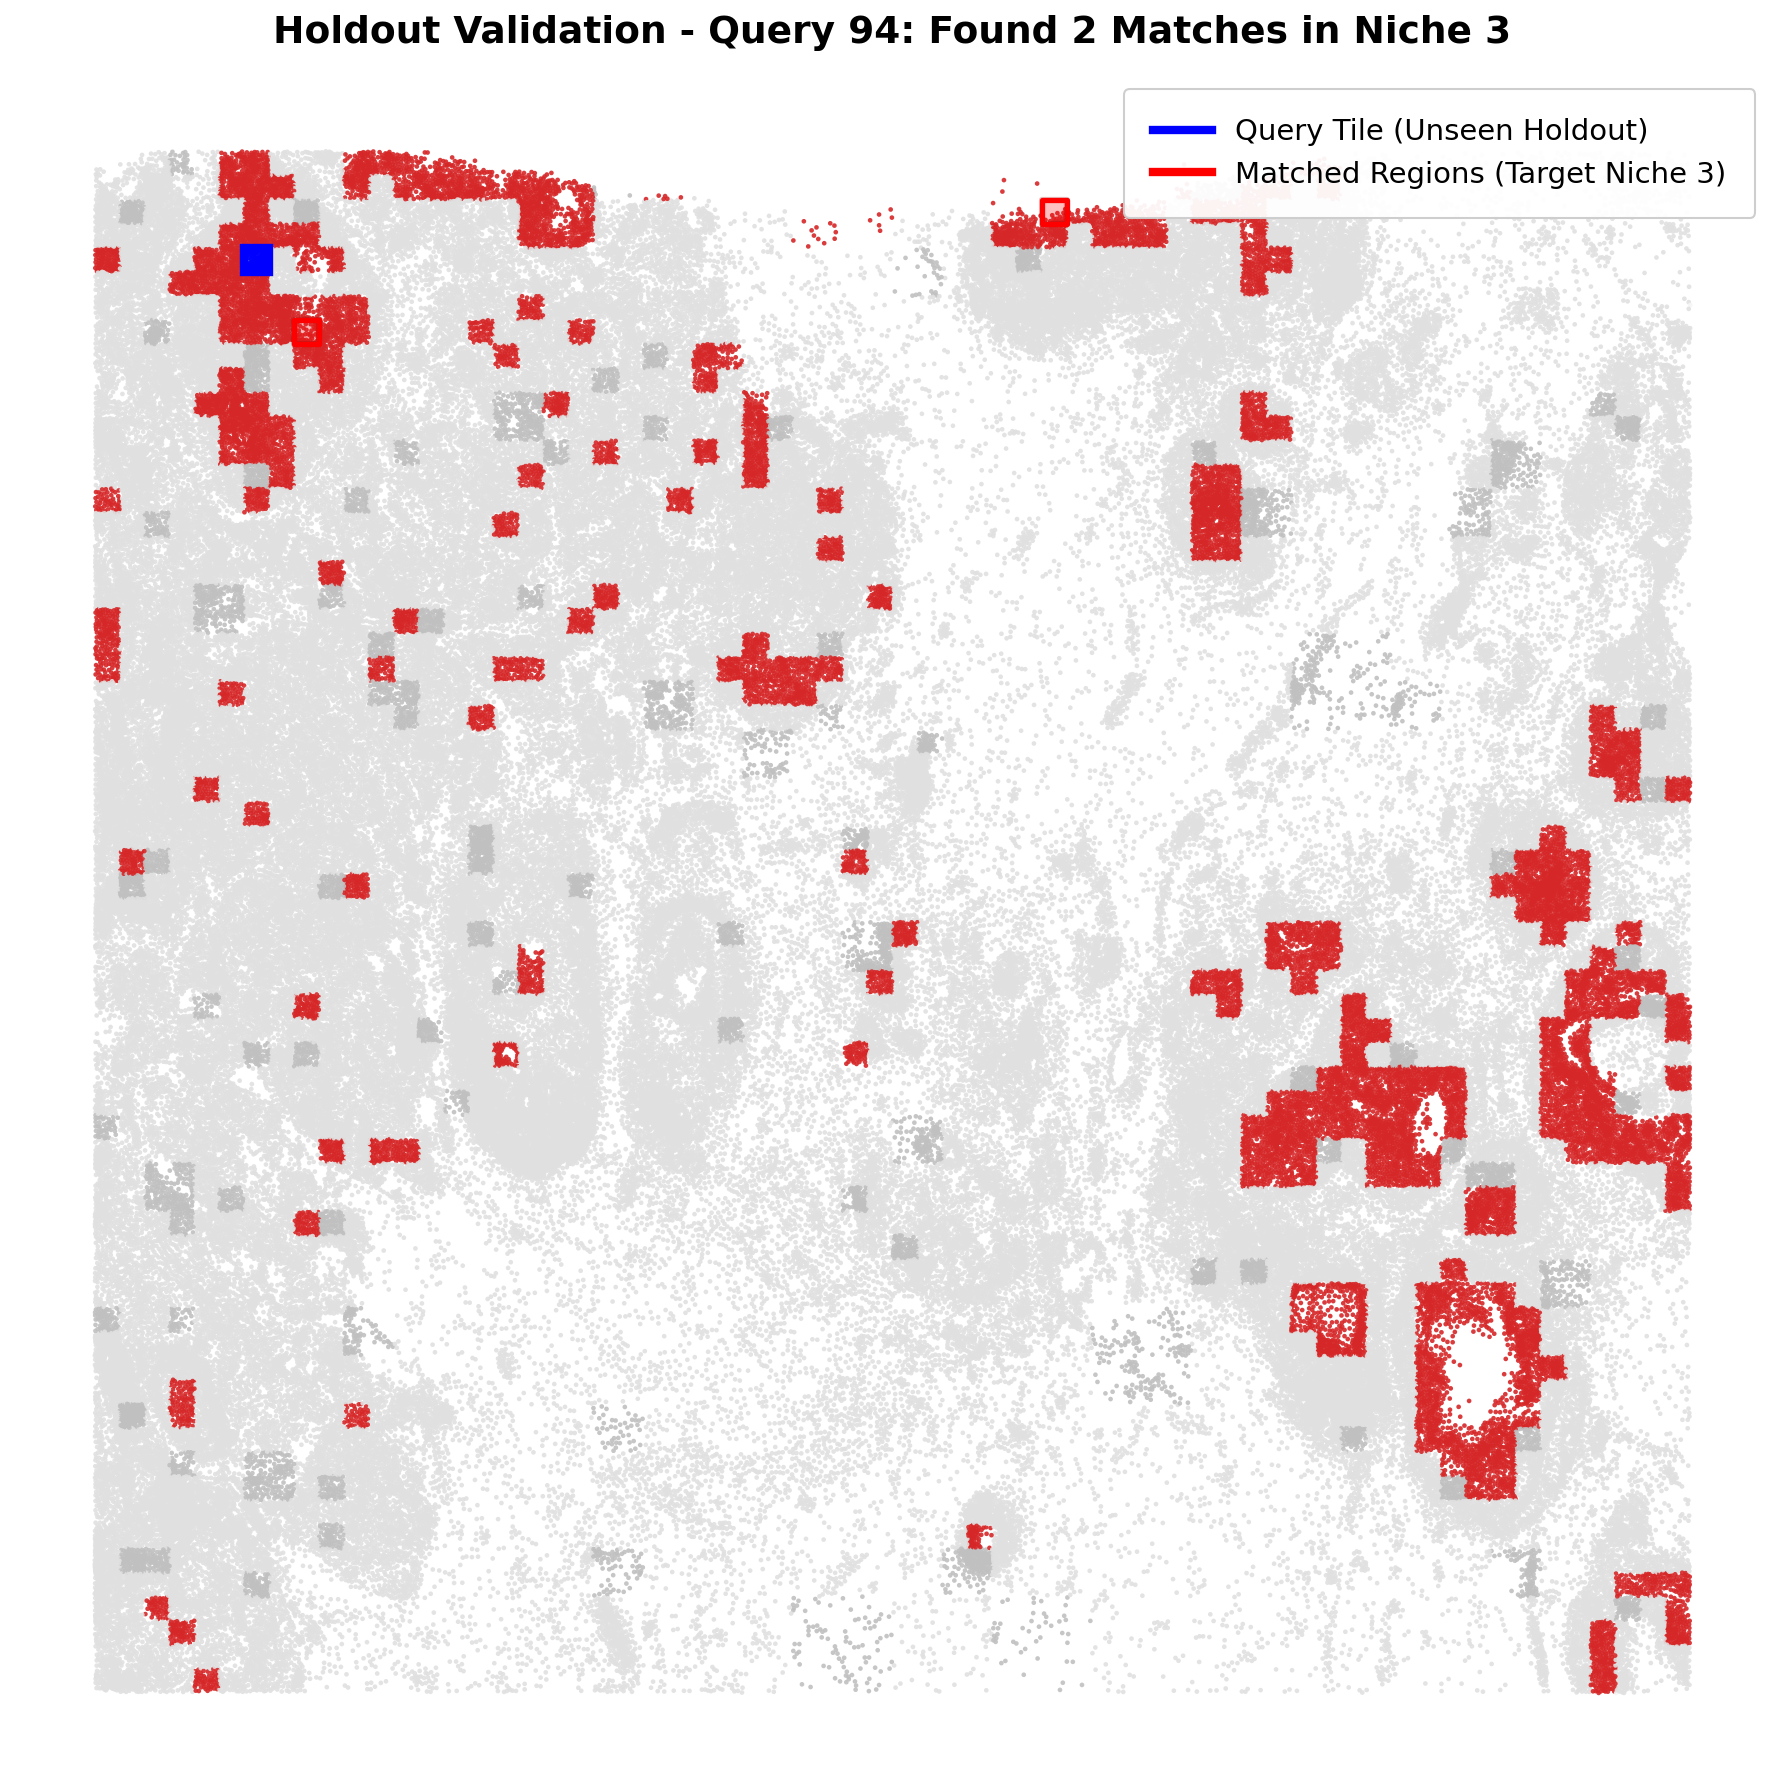

In [55]:
from matplotlib.lines import Line2D

def plot_spindle_test_matches(query_idx, all_matched_train_ids, predicted_clusters, test_tiles, data, adata, tiles):
    if query_idx >= len(all_matched_train_ids):
        print(f"Error: Query index {query_idx} is out of bounds.")
        return
        
    matched_train_ids = all_matched_train_ids[query_idx]
    target_niche = int(predicted_clusters[query_idx])
    held_out_tile = test_tiles[query_idx]

    plt.figure(figsize=(12, 12), dpi=150)
    ax = plt.gca()

    palette = sc.pl.palettes.default_20
    coords = adata.obsm['spatial']
    n_spots = coords.shape[0]
    
    point_colors = np.array(['#f5f5f5'] * n_spots, dtype=object)
    
    # 1. Fill in training/indexed spots
    for spot_id, lab in data.spot_label.items():
        if lab == target_niche:
            point_colors[spot_id] = palette[lab % len(palette)]
        elif lab == -1:
            point_colors[spot_id] = '#f5f5f5'
        else:
            point_colors[spot_id] = '#e0e0e0'
            
    # 2. Fill in all test/holdout spots so they aren't blank
    for test_t in test_tiles:
        for spot_id in test_t.idx:
            point_colors[spot_id] = '#c0c0c0'  # noticeable gray for holdouts

    # 3. Vividly color the specific query tile's spots in bright blue
    for spot_id in held_out_tile.idx:
        point_colors[spot_id] = '#0000ff'

    plt.scatter(coords[:, 0], coords[:, 1], s=5, c=point_colors.tolist(), lw=0, alpha=0.9, zorder=1)

    match_patches = []
    for train_idx in matched_train_ids:
        t = tiles[train_idx]
        bbox = t.bbox if hasattr(t, "bbox") else t["bbox"]
        x0, y0, x1, y1 = bbox
        match_patches.append(Rectangle((x0, y0), x1 - x0, y1 - y0))
        
    if match_patches:
        pc_matches = PatchCollection(
            match_patches,
            facecolor='red',
            edgecolor='darkred',
            linewidths=3,
            alpha=0.25,
            zorder=6
        )
        ax.add_collection(pc_matches)
        
        pc_borders = PatchCollection(
            match_patches,
            facecolor='none',
            edgecolor='red',
            linewidths=2.5,
            zorder=7
        )
        ax.add_collection(pc_borders)

    query_bbox = held_out_tile.bbox if hasattr(held_out_tile, "bbox") else held_out_tile["bbox"]
    qx0, qy0, qx1, qy1 = query_bbox
    query_patch_fill = Rectangle((qx0, qy0), qx1 - qx0, qy1 - qy0, 
                            facecolor='blue', alpha=0.3, zorder=8)
    query_patch_border = Rectangle((qx0, qy0), qx1 - qx0, qy1 - qy0, 
                            fill=False, edgecolor='blue', linewidth=4, zorder=9)
    ax.add_patch(query_patch_fill)
    ax.add_patch(query_patch_border)

    ax.invert_yaxis()
    ax.axis('off')
    
    legend_elements = [
        Line2D([0], [0], color='blue', lw=4, label='Query Tile (Unseen Holdout)'),
        Line2D([0], [0], color='red', lw=4, label=f'Matched Regions (Target Niche {target_niche})')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=14, framealpha=0.95, borderpad=1)
    
    plt.title(f"Holdout Validation - Query {query_idx}: Found {len(matched_train_ids)} Matches in Niche {target_niche}", fontsize=18, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

if len(query_matrices) > 0:
    target_q_idx = 94 if len(query_matrices) > 60 else 0
    print(f"Visualizing search results for unseen query '{target_q_idx}'...")
    plot_spindle_test_matches(target_q_idx, all_matched_train_ids, predicted_clusters, test_tiles, data, adata, tiles)

In [60]:
def check_covariance_significance(query_idx, all_matched_train_ids, test_tile_covs, tile_covs, train_tile_covs, num_permutations=100, verbose=False):
    if query_idx >= len(all_matched_train_ids) or not all_matched_train_ids[query_idx]:
        if verbose: print(f"No matches for query {query_idx} to evaluate significance.")
        return None

    import scipy.stats as stats
    
    def get_flat_cov(cov_data):
        if isinstance(cov_data, dict):
            matrix = cov_data.get('cov', cov_data.get('matrix', cov_data))
        else:
            matrix = cov_data
        
        upper_tri_indices = np.triu_indices_from(matrix, k=1)
        return matrix[upper_tri_indices]

    held_out_cov = test_tile_covs[query_idx]
    top_match_global_id = all_matched_train_ids[query_idx][0]
    matched_cov = tile_covs[top_match_global_id]
    
    query_expr = get_flat_cov(held_out_cov)
    match_expr = get_flat_cov(matched_cov)
    
    true_corr, _ = stats.pearsonr(query_expr, match_expr)

    random_corrs = []
    for _ in range(num_permutations):
        rand_idx = np.random.choice(len(train_tile_covs))
        rand_cov = train_tile_covs[rand_idx]
        
        # Guard against comparing it against the match again
        if rand_cov.get('tile_id') == top_match_global_id:
            continue
            
        rand_expr = get_flat_cov(rand_cov)
        
        if np.std(rand_expr) == 0 or np.std(query_expr) == 0:
            random_corrs.append(0)
            continue
            
        r_corr, _ = stats.pearsonr(query_expr, rand_expr)
        random_corrs.append(r_corr)

    if not random_corrs:
        return None

    p_val = sum(1 for r in random_corrs if r >= true_corr) / len(random_corrs)
    return p_val

def report_all_covariance_significances(all_matched_train_ids, test_tile_covs, tile_covs, train_tile_covs, num_permutations=100):
    print(f"\nRunning large-scale covariance permutation test ({num_permutations} permutations per query)...")
    significant_count = 0
    total_valid = 0
    p_values = []
    
    for query_idx in tqdm(range(len(test_tile_covs)), desc="Evaluating Co-Expression Significance"):
        p_val = check_covariance_significance(query_idx, all_matched_train_ids, test_tile_covs, tile_covs, train_tile_covs, num_permutations, verbose=False)
        if p_val is not None:
            total_valid += 1
            p_values.append(p_val)
            if p_val < 0.05:
                significant_count += 1
                
    if total_valid == 0:
        print("No valid queries with matches to test.")
        return
        
    ratio = significant_count / total_valid
    print("\n" + "="*50)
    print("      GLOBAL SIGNIFICANCE REPORT")
    print("="*50)
    print(f"Total Evaluated Queries:   {total_valid}")
    print(f"Queries with p < 0.05:     {significant_count}")
    print(f"Covariance Match Accuracy: {ratio*100:.2f}%")
    print(f"Mean p-value:              {np.mean(p_values):.4f}")
    print("="*50 + "\n")


report_all_covariance_significances(all_matched_train_ids, test_tile_covs, 
                                    tile_covs, train_tile_covs, num_permutations=100)




Running large-scale covariance permutation test (100 permutations per query)...


Evaluating Co-Expression Significance:   0%|          | 0/104 [00:00<?, ?it/s]


      GLOBAL SIGNIFICANCE REPORT
Total Evaluated Queries:   104
Queries with p < 0.05:     25
Covariance Match Accuracy: 24.04%
Mean p-value:              0.1878



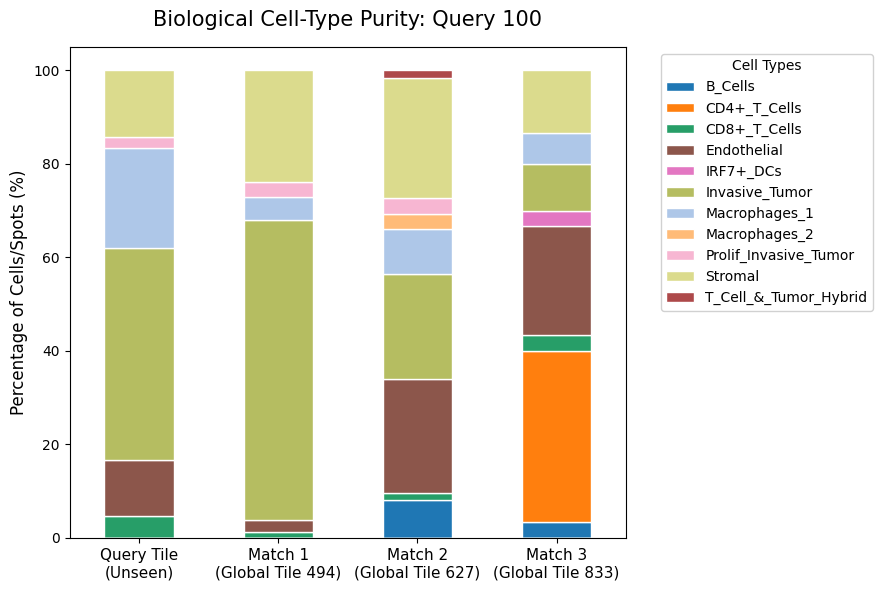

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

def plot_celltype_purity(query_idx, all_matched_train_ids, test_tiles, tiles, adata, cell_type_col='cell_type', top_k=3):
    """
    Plots a stacked bar chart showing the true biological cell types 
    inside the Query tile compared to its top Spindle matches.
    """
    if query_idx >= len(all_matched_train_ids) or not all_matched_train_ids[query_idx]:
        print(f"No matches found to validate for Query {query_idx}.")
        return

    # Extract target tiles
    held_out_tile = test_tiles[query_idx]
    matched_global_ids = all_matched_train_ids[query_idx][:top_k]

    def get_tile_composition(tile):
        spots = getattr(tile, 'idx', getattr(tile, 'spot_idx', getattr(tile, 'indices', [])))
        labels = []
        for s in spots:
            # CRITICAL FIX: Extract actual cell type string from adata.obs
            # Using .iloc because 'spots' are integer positions
            lab = str(adata.obs[cell_type_col].iloc[int(s)])
            labels.append(lab)
        
        total_spots = len(labels)
        if total_spots == 0:
            return {}
        
        counts = pd.Series(labels).value_counts()
        return (counts / total_spots * 100).to_dict()

    # 1. Gather composition data
    comp_dict = {}
    comp_dict['Query Tile\n(Unseen)'] = get_tile_composition(held_out_tile)
    
    for i, global_idx in enumerate(matched_global_ids):
        matched_tile = tiles[global_idx]  
        comp_dict[f'Match {i+1}\n(Global Tile {global_idx})'] = get_tile_composition(matched_tile)

    # 2. Format DataFrame
    df = pd.DataFrame(comp_dict).fillna(0).T
    cell_types = sorted(df.columns)
    df = df[cell_types]

    # 3. Dynamic Color Mapping for Strings
    # Check if Scanpy already has colors assigned for these cell types
    color_key = f"{cell_type_col}_colors"
    if color_key in adata.uns and hasattr(adata.obs[cell_type_col], 'cat'):
        categories = list(adata.obs[cell_type_col].cat.categories)
        scanpy_colors = adata.uns[color_key]
        color_map = dict(zip(categories, scanpy_colors))
        colors = [color_map.get(ct, '#808080') for ct in cell_types] # Fallback to gray if missing
    else:
        # Generate a distinct palette dynamically if no colors are saved
        base_palette = sc.pl.palettes.default_20
        colors = [base_palette[i % len(base_palette)] for i in range(len(cell_types))]

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(9, 6))
    df.plot(kind='bar', stacked=True, color=colors, ax=ax, edgecolor='white', linewidth=1)

    # Formatting
    plt.title(f"Biological Cell-Type Purity: Query {query_idx}", fontsize=15, pad=15)
    plt.ylabel("Percentage of Cells/Spots (%)", fontsize=12)
    plt.xticks(rotation=0, fontsize=11)
    
    # Legend formatting for string categories
    plt.legend(title="Cell Types", bbox_to_anchor=(1.05, 1), loc='upper left', framealpha=0.9)

    plt.tight_layout()
    plt.show()

# NOTE: Change 'cell_type' to whatever column name holds your labels in adata.obs!
# (e.g., 'celltype', 'annotation', 'predicted_labels')
plot_celltype_purity(100, all_matched_train_ids, test_tiles, tiles, adata, cell_type_col='Cluster', top_k=3)